# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Shadiqul Hakim
- Email: mmabdul339@gmail.com
- Id Dicoding: shadiqulbaikhati

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, roc_auc_score
from sklearn.pipeline import Pipeline

# Penyimpanan model
import joblib
import os


### Menyiapkan data yang akan diguankan

## Data Understanding

In [2]:
url = "https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/students_performance/data.csv"

df_raw = pd.read_csv(url, sep=";")
df_raw.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Informasi Umum Dataset

In [3]:
print(f'Jumlah baris   : {df_raw.shape[0]:,}')
print(f'Jumlah kolom   : {df_raw.shape[1]}')
print(f'Missing values : {df_raw.isnull().sum().sum()}')
print(f'Duplikasi      : {df_raw.duplicated().sum()}')

df_raw.info()

Jumlah baris   : 4,424
Jumlah kolom   : 37
Missing values : 0
Duplikasi      : 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-nu

Statistik Deskriptif

In [4]:
df_raw.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.18,0.61,1.00,1.00,1.00,1.00,6.00
Application_mode,4424.0,18.67,17.48,1.00,1.00,17.00,39.00,57.00
Application_order,4424.0,1.73,1.31,0.00,1.00,1.00,2.00,9.00
Course,4424.0,8856.64,2063.57,33.00,9085.00,9238.00,9556.00,9991.00
Daytime_evening_attendance,4424.0,0.89,0.31,0.00,1.00,1.00,1.00,1.00
Previous_qualification,4424.0,4.58,10.22,1.00,1.00,1.00,1.00,43.00
Previous_qualification_grade,4424.0,132.61,13.19,95.00,125.00,133.10,140.00,190.00
Nacionality,4424.0,1.87,6.91,1.00,1.00,1.00,1.00,109.00
Mothers_qualification,4424.0,19.56,15.60,1.00,2.00,19.00,37.00,44.00
Fathers_qualification,4424.0,22.28,15.34,1.00,3.00,19.00,37.00,44.00


Distribusi Target

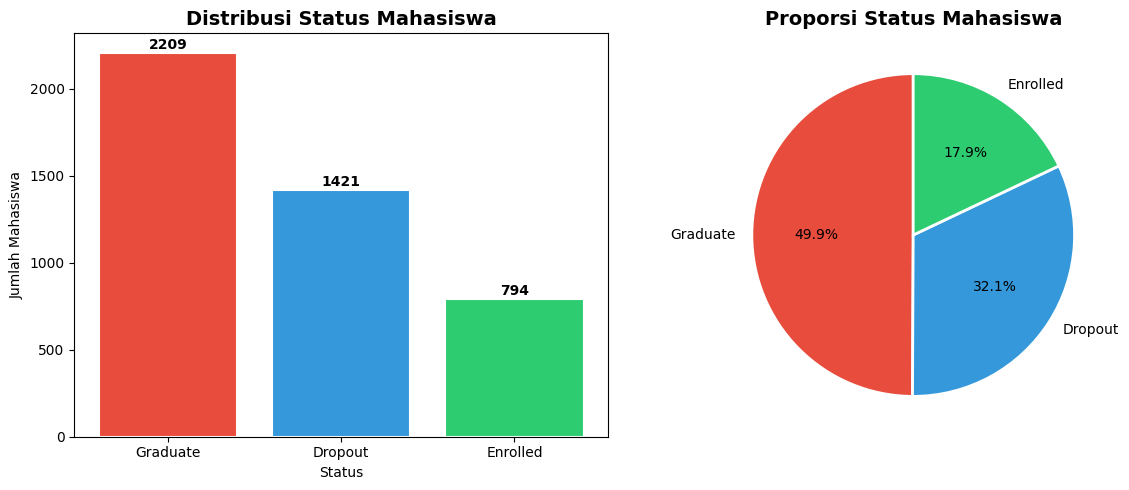

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
target_counts = df_raw['Status'].value_counts()
colors = ['#e74c3c', '#3498db', '#2ecc71']
axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Status Mahasiswa', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Jumlah Mahasiswa')
for i, (label, val) in enumerate(zip(target_counts.index, target_counts.values)):
    axes[0].text(i, val + 20, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    target_counts.values,
    labels=target_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporsi Status Mahasiswa', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_target_distribution.png', bbox_inches='tight')
plt.show()
print(target_counts)

Analisis Faktor-Faktor Utama

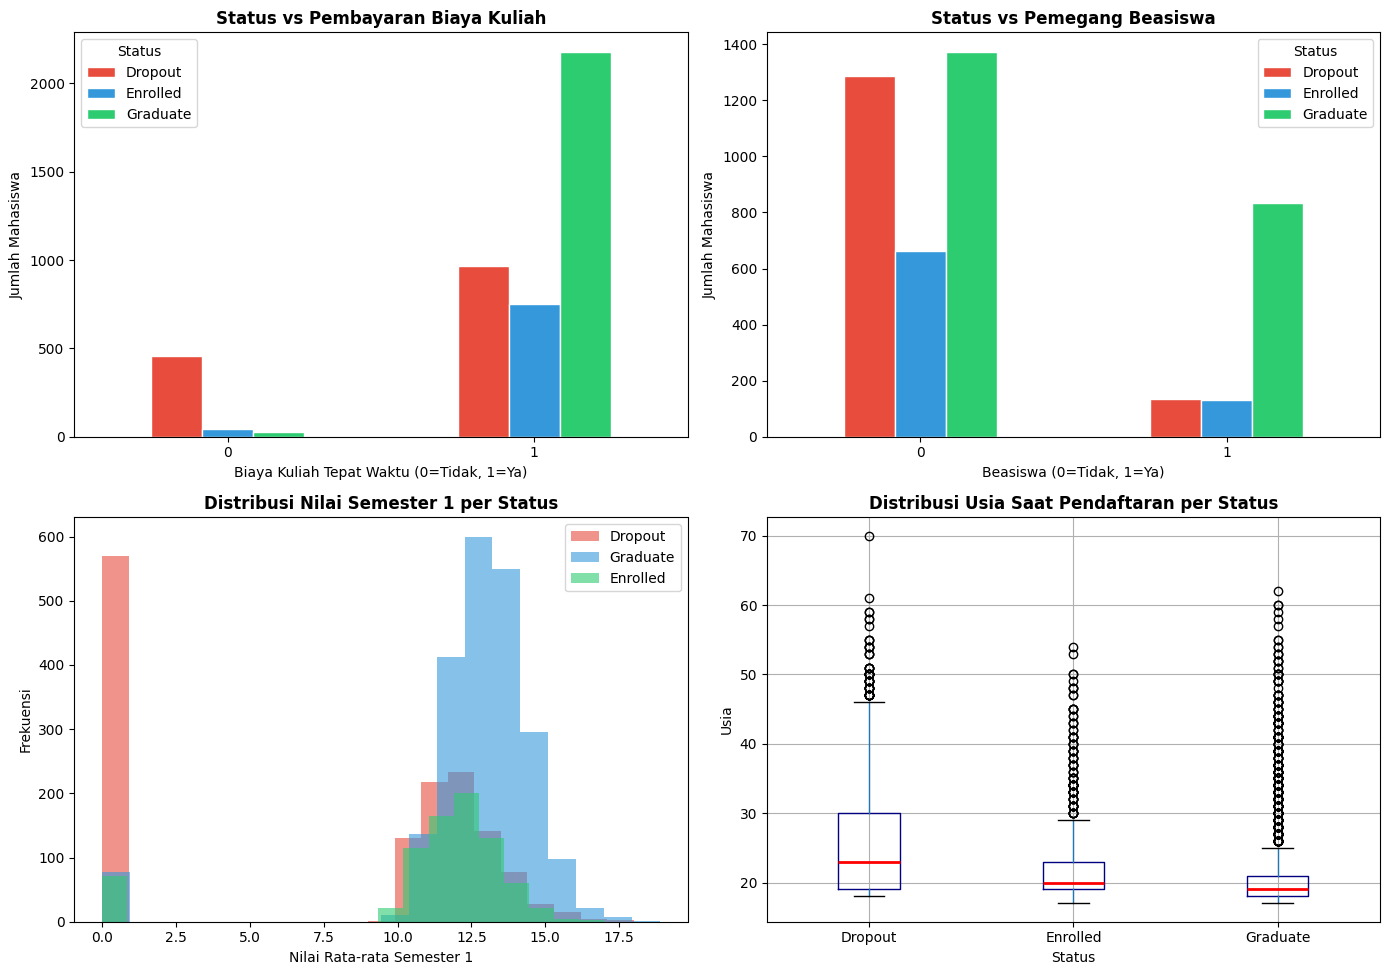

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Dropout vs Tuition fees
tuition_dropout = df_raw.groupby(['Tuition_fees_up_to_date', 'Status']).size().unstack(fill_value=0)
tuition_dropout.plot(kind='bar', ax=axes[0,0], color=colors, edgecolor='white')
axes[0,0].set_title('Status vs Pembayaran Biaya Kuliah', fontweight='bold')
axes[0,0].set_xlabel('Biaya Kuliah Tepat Waktu (0=Tidak, 1=Ya)')
axes[0,0].set_ylabel('Jumlah Mahasiswa')
axes[0,0].legend(title='Status')
axes[0,0].tick_params(axis='x', rotation=0)

# Plot 2: Dropout vs Scholarship
scholar_dropout = df_raw.groupby(['Scholarship_holder', 'Status']).size().unstack(fill_value=0)
scholar_dropout.plot(kind='bar', ax=axes[0,1], color=colors, edgecolor='white')
axes[0,1].set_title('Status vs Pemegang Beasiswa', fontweight='bold')
axes[0,1].set_xlabel('Beasiswa (0=Tidak, 1=Ya)')
axes[0,1].set_ylabel('Jumlah Mahasiswa')
axes[0,1].legend(title='Status')
axes[0,1].tick_params(axis='x', rotation=0)

# Plot 3: Nilai semester 1 per status
for i, (status, color) in enumerate(zip(df_raw['Status'].unique(), colors)):
    subset = df_raw[df_raw['Status'] == status]['Curricular_units_1st_sem_grade']
    axes[1,0].hist(subset, alpha=0.6, label=status, color=color, bins=20)
axes[1,0].set_title('Distribusi Nilai Semester 1 per Status', fontweight='bold')
axes[1,0].set_xlabel('Nilai Rata-rata Semester 1')
axes[1,0].set_ylabel('Frekuensi')
axes[1,0].legend()

# Plot 4: Usia saat pendaftaran
df_raw.boxplot(column='Age_at_enrollment', by='Status', ax=axes[1,1],
               boxprops=dict(color='navy'), medianprops=dict(color='red', linewidth=2))
axes[1,1].set_title('Distribusi Usia Saat Pendaftaran per Status', fontweight='bold')
axes[1,1].set_xlabel('Status')
axes[1,1].set_ylabel('Usia')
plt.suptitle('')

plt.tight_layout()
plt.savefig('plot_eda_factors.png', bbox_inches='tight')
plt.show()

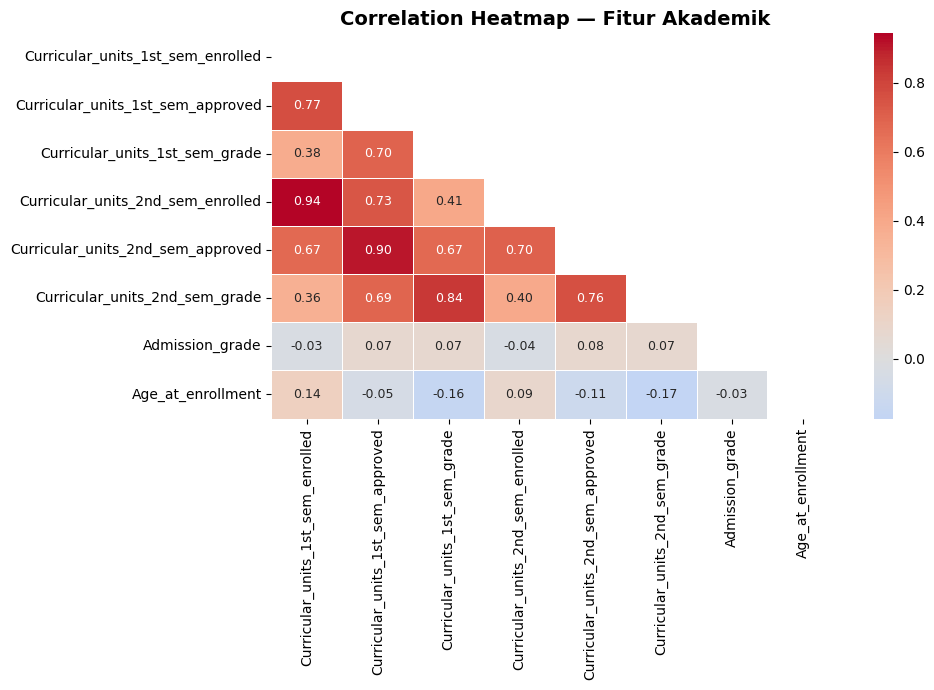

In [9]:
# Correlation heatmap untuk fitur akademik
academic_cols = [
    'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade',
    'Admission_grade', 'Age_at_enrollment'
]

plt.figure(figsize=(10, 7))
corr_matrix = df_raw[academic_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 9}
)
plt.title('Correlation Heatmap — Fitur Akademik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## Data Preparation / Preprocessing

Encode Target

In [11]:
df = df_raw.copy()

# Encode target label
le_target = LabelEncoder()
df['Status_encoded'] = le_target.fit_transform(df['Status'])

print('Mapping Target:')
for cls, code in zip(le_target.classes_, range(len(le_target.classes_))):
    print(f'  {code} → {cls}')

Mapping Target:
  0 → Dropout
  1 → Enrolled
  2 → Graduate


Feature Selection

In [12]:
# Pisahkan fitur dan target
# Drop kolom target asli dan string
FEATURES = [col for col in df.columns if col not in ['Status', 'Status_encoded']]

X = df[FEATURES]
y = df['Status_encoded']

print(f'Jumlah fitur : {X.shape[1]}')
print(f'Jumlah data  : {X.shape[0]}')
print(f'Kelas target : {list(le_target.classes_)}')

Jumlah fitur : 36
Jumlah data  : 4424
Kelas target : ['Dropout', 'Enrolled', 'Graduate']


Train Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training set : {X_train.shape[0]} data ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Testing set  : {X_test.shape[0]} data ({X_test.shape[0]/len(X)*100:.1f}%)')
print()
print('Distribusi kelas pada training set:')
print(pd.Series(y_train).map(dict(enumerate(le_target.classes_))).value_counts())
print()
print('Distribusi kelas pada testing set:')
print(pd.Series(y_test).map(dict(enumerate(le_target.classes_))).value_counts())

Training set : 3539 data (80.0%)
Testing set  : 885 data (20.0%)

Distribusi kelas pada training set:
Status_encoded
Graduate    1767
Dropout     1137
Enrolled     635
Name: count, dtype: int64

Distribusi kelas pada testing set:
Status_encoded
Graduate    442
Dropout     284
Enrolled    159
Name: count, dtype: int64


## Modeling

Membangun Model Random Forest

In [14]:
# Bangun pipeline: Scaler + Random Forest
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

pipeline.fit(X_train, y_train)
print('Model berhasil dilatih.')

Model berhasil dilatih.


Cross Validation

In [15]:
# Stratified K-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='accuracy', n_jobs=-1)

print('Cross-Validation Accuracy (5-Fold):')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'  Mean  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Cross-Validation Accuracy (5-Fold):
  Fold 1: 0.7839
  Fold 2: 0.7655
  Fold 3: 0.7825
  Fold 4: 0.7571
  Fold 5: 0.7567
  Mean  : 0.7691 ± 0.0119


## Evaluation

Prediksi pada Test Set

In [16]:
y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy pada Test Set: {acc:.4f} ({acc*100:.2f}%)')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

Accuracy pada Test Set: 0.7661 (76.61%)

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.83      0.71      0.77       284
    Enrolled       0.51      0.52      0.51       159
    Graduate       0.82      0.89      0.85       442

    accuracy                           0.77       885
   macro avg       0.72      0.71      0.71       885
weighted avg       0.77      0.77      0.76       885



Confusion Matrix

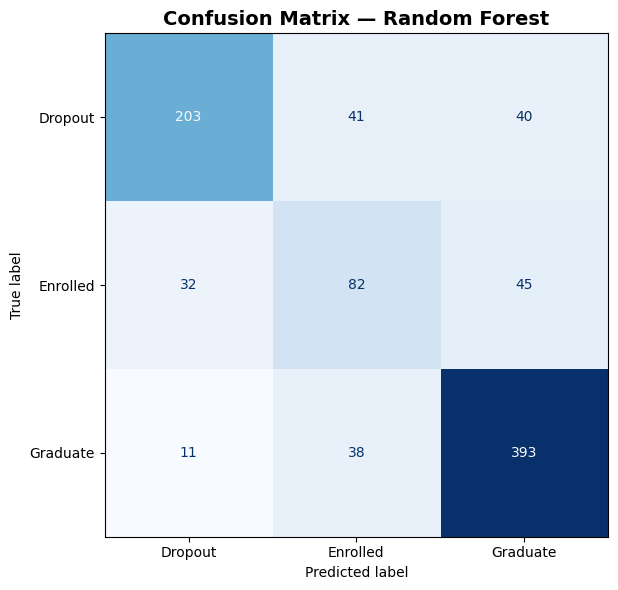

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_confusion_matrix.png', bbox_inches='tight')
plt.show()

Feature Importance

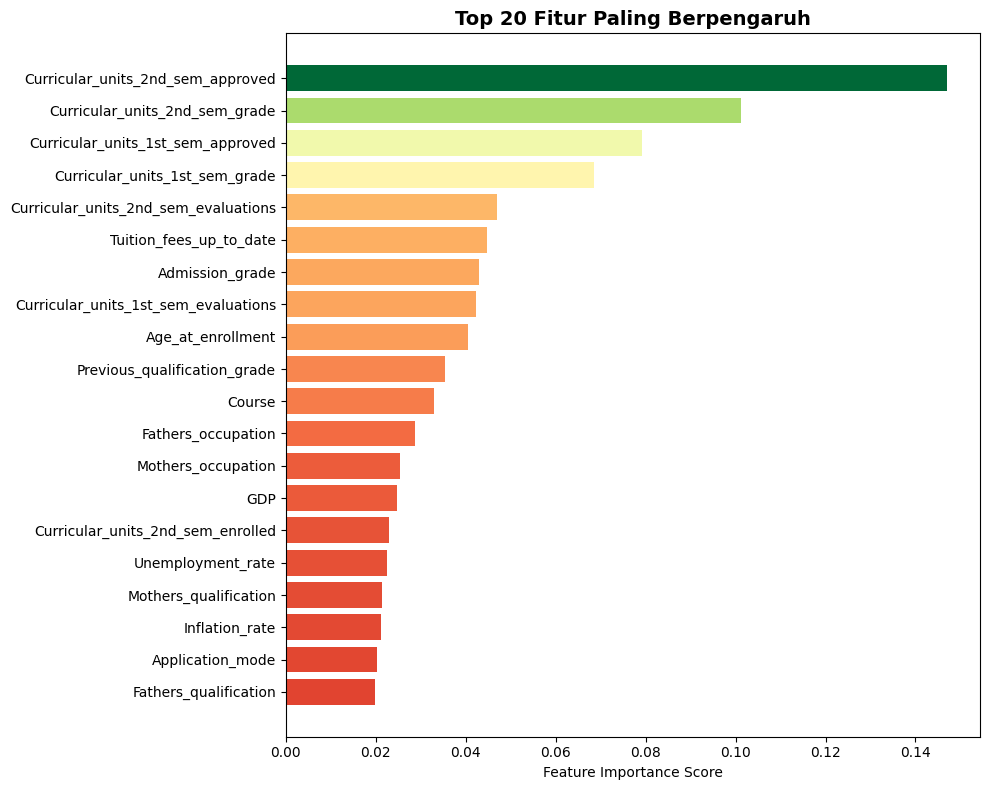

Top 10 Fitur Paling Berpengaruh:
Curricular_units_2nd_sem_approved       0.147003
Curricular_units_2nd_sem_grade          0.101173
Curricular_units_1st_sem_approved       0.079208
Curricular_units_1st_sem_grade          0.068631
Curricular_units_2nd_sem_evaluations    0.046920
Tuition_fees_up_to_date                 0.044691
Admission_grade                         0.043008
Curricular_units_1st_sem_evaluations    0.042205
Age_at_enrollment                       0.040537
Previous_qualification_grade            0.035363


In [18]:
# Ambil feature importance dari model
rf_model = pipeline.named_steps['clf']
importances = pd.Series(rf_model.feature_importances_, index=FEATURES)
top20 = importances.nlargest(20).sort_values()

plt.figure(figsize=(10, 8))
bars = plt.barh(top20.index, top20.values, color=plt.cm.RdYlGn(top20.values / top20.values.max()))
plt.xlabel('Feature Importance Score')
plt.title('Top 20 Fitur Paling Berpengaruh', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 10 Fitur Paling Berpengaruh:')
print(importances.nlargest(10).to_string())

Save Model

In [10]:
os.makedirs('model', exist_ok=True)

# Simpan pipeline (scaler + model)
joblib.dump(pipeline, 'model/random_forest_pipeline.joblib')

# Simpan label encoder
joblib.dump(le_target, 'model/label_encoder.joblib')

# Simpan nama fitur
joblib.dump(FEATURES, 'model/feature_names.joblib')

print('Model disimpan ke folder model/')
print('  - model/random_forest_pipeline.joblib')
print('  - model/label_encoder.joblib')
print('  - model/feature_names.joblib')

Model disimpan ke folder model/
  - model/random_forest_pipeline.joblib
  - model/label_encoder.joblib
  - model/feature_names.joblib
